# PF spatial pseudotime on registered histology

This notebook reproduces the data-driven layer of UniGeneX manuscript **Figure 4E**. It overlays the spatial pseudotime transferred in notebook 04 onto the registered H&E image for pulmonary-fibrosis sample `VUILD106MA`.

Figure 4E is separated from the atlas and mapping calculations because the registered TIFF is approximately 2.8 GB. This notebook therefore needs only notebook 04's compact output table, the H&E image, and its Xenium-to-image scale factor. It does not reopen the atlas, the spatial UGE matrix, or either query-to-atlas connectivity matrix.

## Data contract

Download and extract the modular archives from the [UniGeneX PF Zenodo record](https://doi.org/10.5281/zenodo.22489310). Set `UNIGENEX_DATA_DIR` to the extracted data directory containing `PF/`. By default, the notebook reads the output of notebook 04 from `outputs/04_epithelial_trajectory_and_spatial_pseudotime/` relative to the working directory. If notebook 04 used a custom output location, set `UNIGENEX_FIGURE4_RESULTS_DIR` to that directory.

| Input | Role |
|---|---|
| `spatial_pseudotime.csv.gz` from notebook 04 | Per-cell transferred pseudotime and Xenium coordinates |
| `PF/sp_map_to_sc_Epi/histology/GSM7990548_VUILD106MA_registered_HE.tif` | Registered H&E image |
| `PF/sp_map_to_sc_Epi/histology/Xenium_sf.npy` | Conversion from Xenium coordinates to image pixels |

Generated files are written to `outputs/05_spatial_pseudotime_histology/` by default. Set `UNIGENEX_OUTPUT_DIR` to choose another directory. The source TIFF is opened read-only and is never rewritten.

In [1]:
from pathlib import Path
from importlib.metadata import version
import gc
import os
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import sparse
from scipy.spatial import cKDTree

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
EPITHELIAL_DIR = DATA_ROOT / "PF" / "sp_map_to_sc_Epi"
HISTOLOGY_DIR = EPITHELIAL_DIR / "histology"
HISTOLOGY_PATH = (
    HISTOLOGY_DIR / "GSM7990548_VUILD106MA_registered_HE.tif"
)
SCALE_FACTOR_PATH = HISTOLOGY_DIR / "Xenium_sf.npy"
FIGURE4_RESULTS_DIR = Path(
    os.environ.get(
        "UNIGENEX_FIGURE4_RESULTS_DIR",
        Path.cwd() / "outputs"
        / "04_epithelial_trajectory_and_spatial_pseudotime",
    )
).expanduser().resolve()
PSEUDOTIME_PATH = FIGURE4_RESULTS_DIR / "spatial_pseudotime.csv.gz"
OUTPUT_DIR = Path(
    os.environ.get(
        "UNIGENEX_OUTPUT_DIR",
        Path.cwd() / "outputs" / "05_spatial_pseudotime_histology",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE = "VUILD106MA"
CROP_X = (1800.0, 4250.0)
CROP_Y = (1000.0, 3200.0)
LOWER_QUANTILE = 0.05
UPPER_QUANTILE = 0.95
GRID_SIZE = int(os.environ.get("UNIGENEX_SPATIAL_GRID_SIZE", "300"))
DISTANCE_SQUARED_CUTOFF = 5e4
EXP_DISTANCE_STD = 1e6
HISTOLOGY_MAX_DISPLAY_DIMENSION = int(
    os.environ.get("UNIGENEX_HISTOLOGY_MAX_DIMENSION", "3600")
)

required_files = [PSEUDOTIME_PATH, HISTOLOGY_PATH, SCALE_FACTOR_PATH]
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    formatted = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing Figure 4E inputs:\n" + formatted + "\n"
        "Run notebook 04 first and set UNIGENEX_DATA_DIR to the "
        "directory containing PF/."
    )
if GRID_SIZE < 2:
    raise ValueError("UNIGENEX_SPATIAL_GRID_SIZE must be at least 2.")

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Data root: {DATA_ROOT}")
print(f"Notebook 04 results: {FIGURE4_RESULTS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(
    f"Python {platform.python_version()}, Pillow {version('Pillow')}, "
    f"SciPy {version('scipy')}"
)

Data root: /import/home2/xwanaf/Img2Expr/data/Reproducibility_data
Notebook 04 results: /import/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/Validation/Real_data_PF/outputs/04_epithelial_trajectory_and_spatial_pseudotime
Output directory: /import/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/Validation/Real_data_PF/outputs/05_spatial_pseudotime_histology
Python 3.10.20, Pillow 12.2.0, SciPy 1.15.3


## Select the manuscript sample and crop

Notebook 04 retained spatial cells with more than 4 units of fuzzy connectivity mass to the curated AT1-to–Aberrant Basaloid trajectory. Here we first clip pseudotime at the global 5th and 95th percentiles, following the historical full-tissue rendering, so that a few extreme cells do not dominate the color scale. The clipping bounds are calculated before selecting the sample.

The manuscript view is the crop used in the historical PF notebook: Xenium x coordinates 1800–4250 and y coordinates 1000–3200. These bounds are converted to registered-image pixels only after loading the stored scale factor.

In [2]:
spatial_pseudotime = pd.read_csv(PSEUDOTIME_PATH)
required_columns = {
    "query_id", "sample", "cell_id", "x_centroid",
    "y_centroid", "spatial_pseudotime",
}
missing_columns = required_columns.difference(spatial_pseudotime.columns)
if missing_columns:
    raise KeyError(
        f"{PSEUDOTIME_PATH} is missing columns: {sorted(missing_columns)}"
    )
if spatial_pseudotime["query_id"].duplicated().any():
    raise ValueError("Notebook 04 output contains duplicated query IDs.")
for column in ["x_centroid", "y_centroid", "spatial_pseudotime"]:
    spatial_pseudotime[column] = pd.to_numeric(
        spatial_pseudotime[column], errors="coerce"
    )
finite = np.isfinite(
    spatial_pseudotime[["x_centroid", "y_centroid", "spatial_pseudotime"]]
).all(axis=1)
if not finite.all():
    raise ValueError(
        f"Notebook 04 output contains {(~finite).sum():,} non-finite rows."
    )

clip_lower, clip_upper = np.quantile(
    spatial_pseudotime["spatial_pseudotime"],
    [LOWER_QUANTILE, UPPER_QUANTILE],
)
spatial_pseudotime["plot_pseudotime"] = spatial_pseudotime[
    "spatial_pseudotime"
].clip(lower=clip_lower, upper=clip_upper)

sample_cells = spatial_pseudotime.loc[
    spatial_pseudotime["sample"].astype(str).eq(SAMPLE)
].copy()
in_crop = (
    sample_cells["x_centroid"].between(*CROP_X, inclusive="both")
    & sample_cells["y_centroid"].between(*CROP_Y, inclusive="both")
)
crop_cells = sample_cells.loc[in_crop].copy()
if crop_cells.empty:
    raise ValueError("No retained VUILD106MA cells fall inside the manuscript crop.")

print(f"All retained spatial cells: {len(spatial_pseudotime):,}")
print(f"{SAMPLE} retained cells: {len(sample_cells):,}")
print(f"Cells inside the manuscript crop: {len(crop_cells):,}")
print(f"Global 5th/95th-percentile clip: {clip_lower:.4f}, {clip_upper:.4f}")
display(
    crop_cells["plot_pseudotime"].describe().rename("cropped pseudotime")
)

All retained spatial cells: 22,854
VUILD106MA retained cells: 1,367
Cells inside the manuscript crop: 302
Global 5th/95th-percentile clip: 0.3338, 0.6682


count    302.000000
mean       0.525026
std        0.087099
min        0.333758
25%        0.470206
50%        0.532768
75%        0.587740
max        0.668180
Name: cropped pseudotime, dtype: float64

## Reconstruct the spatial pseudotime surface

The historical notebook evaluated a 300×300 grid. At every grid point it retained cells with squared pixel distance below `5e4` and calculated a Gaussian-weighted mean:

$$Z(p)=\frac{\sum_i t_i\,I(d_{pi}^2<5\times10^4)\exp[-d_{pi}^2/(10^6s)]}{\sum_i I(d_{pi}^2<5\times10^4)\exp[-d_{pi}^2/(10^6s)]},$$

where $t_i$ is clipped spatial pseudotime and $s$ is the Xenium-to-image scale factor. The original code scanned every cell over the complete grid twice. Here a KD-tree first identifies exactly the same cell-grid pairs within the distance cutoff, after which sparse matrix multiplication evaluates the same numerator and denominator. This changes computational organization, not the mathematical estimator.

In [3]:
scale_values = np.asarray(
    np.load(SCALE_FACTOR_PATH, allow_pickle=True), dtype=float
).reshape(-1)
if scale_values.size != 1 or not np.isfinite(scale_values[0]):
    raise ValueError(f"Expected one finite scale factor in {SCALE_FACTOR_PATH}.")
scale_factor = float(scale_values[0])
if scale_factor <= 0:
    raise ValueError("The Xenium-to-image scale factor must be positive.")

x_pixels = crop_cells["x_centroid"].to_numpy() * scale_factor
y_pixels = crop_cells["y_centroid"].to_numpy() * scale_factor
pseudotime_values = crop_cells["plot_pseudotime"].to_numpy()
grid_x = np.linspace(x_pixels.min(), x_pixels.max(), GRID_SIZE)
grid_y = np.linspace(y_pixels.min(), y_pixels.max(), GRID_SIZE)
mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([mesh_x.ravel(), mesh_y.ravel()])
cell_points = np.column_stack([x_pixels, y_pixels])

grid_tree = cKDTree(grid_points)
cell_tree = cKDTree(cell_points)
neighbor_distances = grid_tree.sparse_distance_matrix(
    cell_tree,
    max_distance=np.sqrt(DISTANCE_SQUARED_CUTOFF),
    output_type="coo_matrix",
)
weights = sparse.coo_matrix(
    (
        np.exp(-(neighbor_distances.data ** 2) / (EXP_DISTANCE_STD * scale_factor)),
        (neighbor_distances.row, neighbor_distances.col),
    ),
    shape=(len(grid_points), len(cell_points)),
).tocsr()
weight_sum = np.asarray(weights.sum(axis=1)).ravel()
weighted_time_sum = np.asarray(weights.dot(pseudotime_values)).ravel()
surface_flat = np.zeros(len(grid_points), dtype=np.float64)
has_support = weight_sum > 0
surface_flat[has_support] = weighted_time_sum[has_support] / weight_sum[has_support]
surface = surface_flat.reshape(mesh_x.shape)
support = weight_sum.reshape(mesh_x.shape)

positive_surface = surface[surface > 0]
if not len(positive_surface):
    raise ValueError("The smoothing grid has no supported pixels.")
contour_levels = np.linspace(
    positive_surface.min(), surface.max() + 0.01, 12
)
if positive_surface.min() > 0.01:
    contour_levels = np.concatenate([[0.01], contour_levels])

np.savez_compressed(
    OUTPUT_DIR / "Figure4E_smoothed_surface.npz",
    mesh_x=mesh_x, mesh_y=mesh_y, spatial_pseudotime=surface,
    weight_sum=support, contour_levels=contour_levels,
)
print(f"Xenium-to-image scale factor: {scale_factor:.7f}")
print(f"Grid: {GRID_SIZE} × {GRID_SIZE}")
print(f"Supported grid locations: {has_support.sum():,} ({has_support.mean():.1%})")
print(f"Cell-grid pairs within cutoff: {neighbor_distances.nnz:,}")

Xenium-to-image scale factor: 4.7058821
Grid: 300 × 300
Supported grid locations: 16,311 (18.1%)
Cell-grid pairs within cutoff: 44,237


## Load only the registered H&E crop

The TIFF is much larger than the manuscript panel. Pillow opens it lazily, after which only the registered crop is retained and downsampled for display. The image-array dimensions change, but `imshow` is assigned the original full-resolution pixel extent, so the contour coordinates remain registered correctly. Neither the pixel crop nor the downsample factor changes the pseudotime surface.

In [4]:
pixel_crop = (
    int(round(CROP_X[0] * scale_factor)),
    int(round(CROP_Y[0] * scale_factor)),
    int(round(CROP_X[1] * scale_factor)),
    int(round(CROP_Y[1] * scale_factor)),
)
Image.MAX_IMAGE_PIXELS = None
with Image.open(HISTOLOGY_PATH) as full_image:
    full_image_size = full_image.size
    left, upper, right, lower = pixel_crop
    if not (
        0 <= left < right <= full_image_size[0]
        and 0 <= upper < lower <= full_image_size[1]
    ):
        raise ValueError(
            f"Pixel crop {pixel_crop} is outside TIFF size {full_image_size}."
        )
    histology_crop = full_image.crop(pixel_crop).convert("RGB")

original_crop_size = histology_crop.size
histology_crop.thumbnail(
    (HISTOLOGY_MAX_DISPLAY_DIMENSION, HISTOLOGY_MAX_DISPLAY_DIMENSION),
    Image.Resampling.LANCZOS,
)
display_crop_size = histology_crop.size
histology_display = np.asarray(histology_crop)
del histology_crop
gc.collect()

print(f"Full TIFF dimensions: {full_image_size}")
print(f"Full-resolution pixel crop: {pixel_crop}")
print(f"Crop dimensions before display downsampling: {original_crop_size}")
print(f"Displayed crop dimensions: {display_crop_size}")

Full TIFF dimensions: (28462, 33048)
Full-resolution pixel crop: (8471, 4706, 20000, 15059)
Crop dimensions before display downsampling: (11529, 10353)
Displayed crop dimensions: (3600, 3233)


## Figure 4E — spatial pseudotime-derived disease severity

The registered H&E crop is shown beneath the continuous pseudotime surface. The reversed Spectral palette follows the manuscript: lower values are labeled mild, intermediate values moderate, and higher values severe. The qualitative colorbar uses the same color normalization as the contour overlay, with moderate placed at the midpoint of the displayed scale. These labels describe low, intermediate, and high spatial pseudotime rather than clinical thresholds. Transparency is 0.6, matching the historical plotting code.

The colored rectangular callouts and panel letters visible in the assembled main figure were editorial annotations linking regions to later panels; they are not part of the pseudotime calculation and are not added to the reproducibility output below.

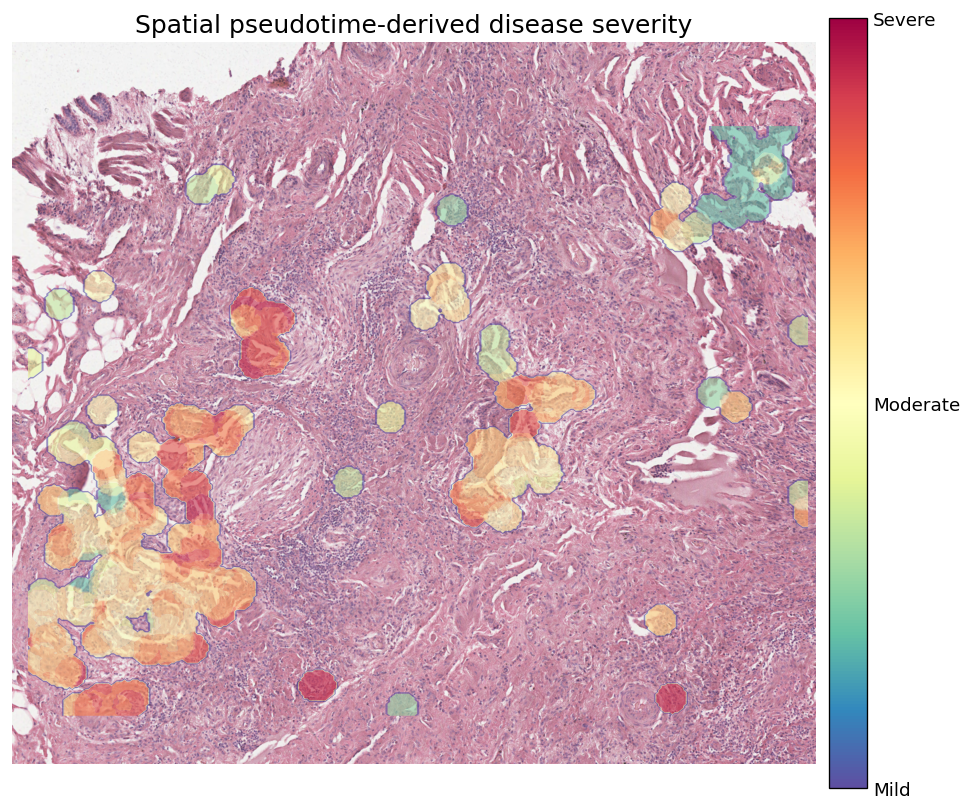

Saved Figure 4E to /import/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/Validation/Real_data_PF/outputs/05_spatial_pseudotime_histology/Figure4E_spatial_pseudotime_histology.png


In [5]:
pseudotime_cmap = mpl.colormaps["Spectral_r"]
color_norm = mpl.colors.Normalize(vmin=0.25, vmax=contour_levels[-1])
contour_colors = pseudotime_cmap(color_norm(contour_levels))
left, upper, right, lower = pixel_crop

fig, ax = plt.subplots(figsize=(8.2, 7.4), dpi=120)
ax.imshow(
    histology_display,
    origin="upper",
    extent=(left, right, lower, upper),
    interpolation="bilinear",
    alpha=0.9,
    zorder=1,
)
contour = ax.contourf(
    mesh_x, mesh_y, surface,
    levels=contour_levels, colors=contour_colors,
    alpha=0.6, antialiased=True, zorder=40,
)
ax.set_xlim(left, right)
ax.set_ylim(lower, upper)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Spatial pseudotime-derived disease severity", fontsize=15)

severity_midpoint = (color_norm.vmin + color_norm.vmax) / 2
severity_mappable = mpl.cm.ScalarMappable(
    norm=color_norm, cmap=pseudotime_cmap,
)
severity_mappable.set_array([])
colorbar = fig.colorbar(
    severity_mappable, ax=ax, pad=0.015, fraction=0.045,
)
severity_ticks = [color_norm.vmin, severity_midpoint, color_norm.vmax]
colorbar.set_ticks(severity_ticks)
colorbar.set_ticklabels(["Mild", "Moderate", "Severe"])
colorbar.ax.tick_params(length=0, labelsize=11)
fig.tight_layout()
figure_path = OUTPUT_DIR / "Figure4E_spatial_pseudotime_histology.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", pad_inches=0.08)
plt.show()
plt.close(fig)

parameter_table = pd.DataFrame([
    {"parameter": "sample", "value": SAMPLE},
    {"parameter": "input_spatial_cells", "value": len(spatial_pseudotime)},
    {"parameter": "sample_cells", "value": len(sample_cells)},
    {"parameter": "crop_cells", "value": len(crop_cells)},
    {"parameter": "global_clip_quantiles", "value": "0.05,0.95"},
    {"parameter": "global_clip_values", "value": f"{clip_lower},{clip_upper}"},
    {"parameter": "crop_x_xenium", "value": f"{CROP_X[0]},{CROP_X[1]}"},
    {"parameter": "crop_y_xenium", "value": f"{CROP_Y[0]},{CROP_Y[1]}"},
    {"parameter": "xenium_to_image_scale_factor", "value": scale_factor},
    {"parameter": "grid_size", "value": GRID_SIZE},
    {"parameter": "distance_squared_cutoff", "value": DISTANCE_SQUARED_CUTOFF},
    {"parameter": "exponential_distance_std", "value": EXP_DISTANCE_STD},
    {"parameter": "severity_color_vmin", "value": color_norm.vmin},
    {"parameter": "severity_color_midpoint", "value": severity_midpoint},
    {"parameter": "severity_color_vmax", "value": color_norm.vmax},
])
parameter_table.to_csv(
    OUTPUT_DIR / "Figure4E_parameters.tsv", sep="\t", index=False
)
print(f"Saved Figure 4E to {figure_path}")

## Interpretation

The overlay is a spatial visualization of atlas-derived pseudotime, not a pseudotime inferred from H&E morphology. Tissue coordinates enter only after notebook 04 has completed the expression-based atlas mapping and pseudotime transfer. Local averaging makes spatially coherent regions visible over histology, while unsupported grid locations remain transparent.

For auditing or alternative rendering, `Figure4E_smoothed_surface.npz` stores the exact grid coordinates, averaged pseudotime surface, support weights, and contour levels used in the panel. `Figure4E_parameters.tsv` records the sample, crop, clipping bounds, scale factor, and smoothing parameters.